<b>Setup</b>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

<b>Import der Daten</b>


In [2]:
df = pd.read_csv("../data/ai_student_impact_dataset.csv")

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


<b>Der Datensatz im Überblick:</b>

Zu sehen sind die jeweiligen Spalten des Datensatzes sowie die Anzahl der Einträge und dem jeweilig verwendeten Datentyp.


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

(50000, 16)

**Eine ausführlichere Beschreibung der Spaltenbezeichnungen und ihrer Bedeutung:**
**Student_ID** => Eine eindeutige Identifikationsnummer für jeden Studierenden<br>
**Major_Category** => Die Studienrichtung (STEM, Business, Med, etc.)<br>
**Year_of_Study** => Akademischer Standpunkt: Freshman, Senior, Junior, Graduate, Sophomore<br>
**Pre_Semester_GPA** => Notendurchschnitt _vor_ dem aktuellen Semester der Datenerhebung (1.0 - 4.0)<br>
**Post_Semester_GPA** => Notendurchschnitt zum _Ende_ des aktuellen Semesters der Datenerhebung<br>
**Weekly_GenAI_Hours** => Durchschn. Anzahl an Stunden, die ein Studierender mit der Nutzung von KI-Tools verbracht hat<br>
**Primary_Use_Case** => Hauptzweck der Nutzung der KI <br>
**Prompt_Engineering_Skill** => Selbsteinschätzung der effektiven Prompt-Generierung<br>
**Tool_Diversity** => Anzahl der eingesetzten und einzigartigen KI-Tools<br>
**Paid_Subscription** => Ob ein Student für die Nutzung des KI-Tools ein Abonnement nutzt<br>
**Traditional_Study_Hours** => Wöchentliche Stunden, die ein Studierender für traditionelle Lernmethoden aufwendet<br>
**Perceived_AI_Dependency** => Selbsteinschätzung der eigenen KI-Abhängigkeit der Stundierenden<br>
**Institutional_Policy** => Der Standpunkt der Institution zur Anwendbarkeit von KI-Tools (Verboten, Erlaubt mit Zitation etc.)<br>
**Anxiety_Level_During_Exams** => Einschätzung der empfundenen Angst während Klausuren 0(minimal) - 10(erheblich)<br>
**Skill_Retention_Score** => Messwerte, wie gut ein Studierender nach dem Semester erlernte Fähigkeiten beibehalten konnte<br>
**Burnout_Risk_Level** => Einschätzung eines Burnout-Risikos (Leicht, Mittel, Hoch)<br>

<b>Leere Einträge finden und entfernen:</b>

Entfernt zunächst alle leeren Zellen, final wird eine Liste ausgegeben die die jeweilige Anzahl an entfernten Zellen in der Spalte enthält.


In [4]:
df.isnull().sum()
df_clean = df.dropna()

df_clean.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

<b>Kategorische Spalten finden (Spalten ohne numerische Werte):</b>

Diese lassen sich am Datentyp(object) erkennen, anhand dessen sie auch gefiltert werden können


In [5]:
categorical_columns = df_clean.select_dtypes(include=["object"]).columns

print("Kategorische Spalten:", categorical_columns)

Kategorische Spalten: Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='str')


C:\Users\Patrick Sichma\AppData\Local\Temp\ipykernel_20080\1053059782.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include=["object"]).columns


<b>One-Hot.Encoding durchführen:</b>

Führt zunächst das One-Hot.Encoding durch, visualisiert danach die entstandene Tabelle mit den neuen Spalten.<br>
drop_first = erste Möglickeit für Dummy Entries wird gedroppt/als Standard gesetzt, d.h gibt es k-1 neue Spalten wenn k für die Möglichkeiten steht, die eine Kategorische Variable annehmen kann.


In [6]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)

df_encoded.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium
0,100001,2.418,23.31,1,True,8.13,5,6,2.393,86.44,...,False,False,False,False,True,False,True,False,False,False
1,100002,3.821,1.12,5,False,16.65,3,9,3.696,69.39,...,False,False,True,False,False,False,True,False,True,False
2,100003,3.398,21.26,2,False,10.35,5,9,3.499,73.93,...,False,False,False,True,True,False,False,True,False,True
3,100004,3.789,1.82,4,False,15.23,2,2,4.000,63.58,...,False,False,False,False,False,True,True,False,False,True
4,100005,3.635,9.29,4,False,12.55,4,4,3.798,100.00,...,True,False,False,False,False,False,True,False,False,True


**Beispiel für One-Hot-Encoding anhand Burnout-Risk**

Das Burnout-Level wird in den Werten _High_, _Medium_ und _Low_ wiedergegeben.<br>
Für das One-Hot-Encoding wird die ursprüngliche Spalte Burnout_Risk_Level in _Burnout_Risk_Level_Low_ und _Burnout_Risk_Level_Medium_ aufgeteilt. Aufgrund von **drop_first=True** wird _Burnout_Risk_Level_High_ als Standard genommen.

<b>Pairplot erstellen:</b>

bei der Erstellung werden nur die urspünglich nummerischen Spalten verwendet, da durch das One-Hot-Encoding viele Spalten entstehen die das pairplot unübersichtlicher machen. Konkret werden die Spalten angezeigt, welche ursprünglich int und float Werte enthalten.


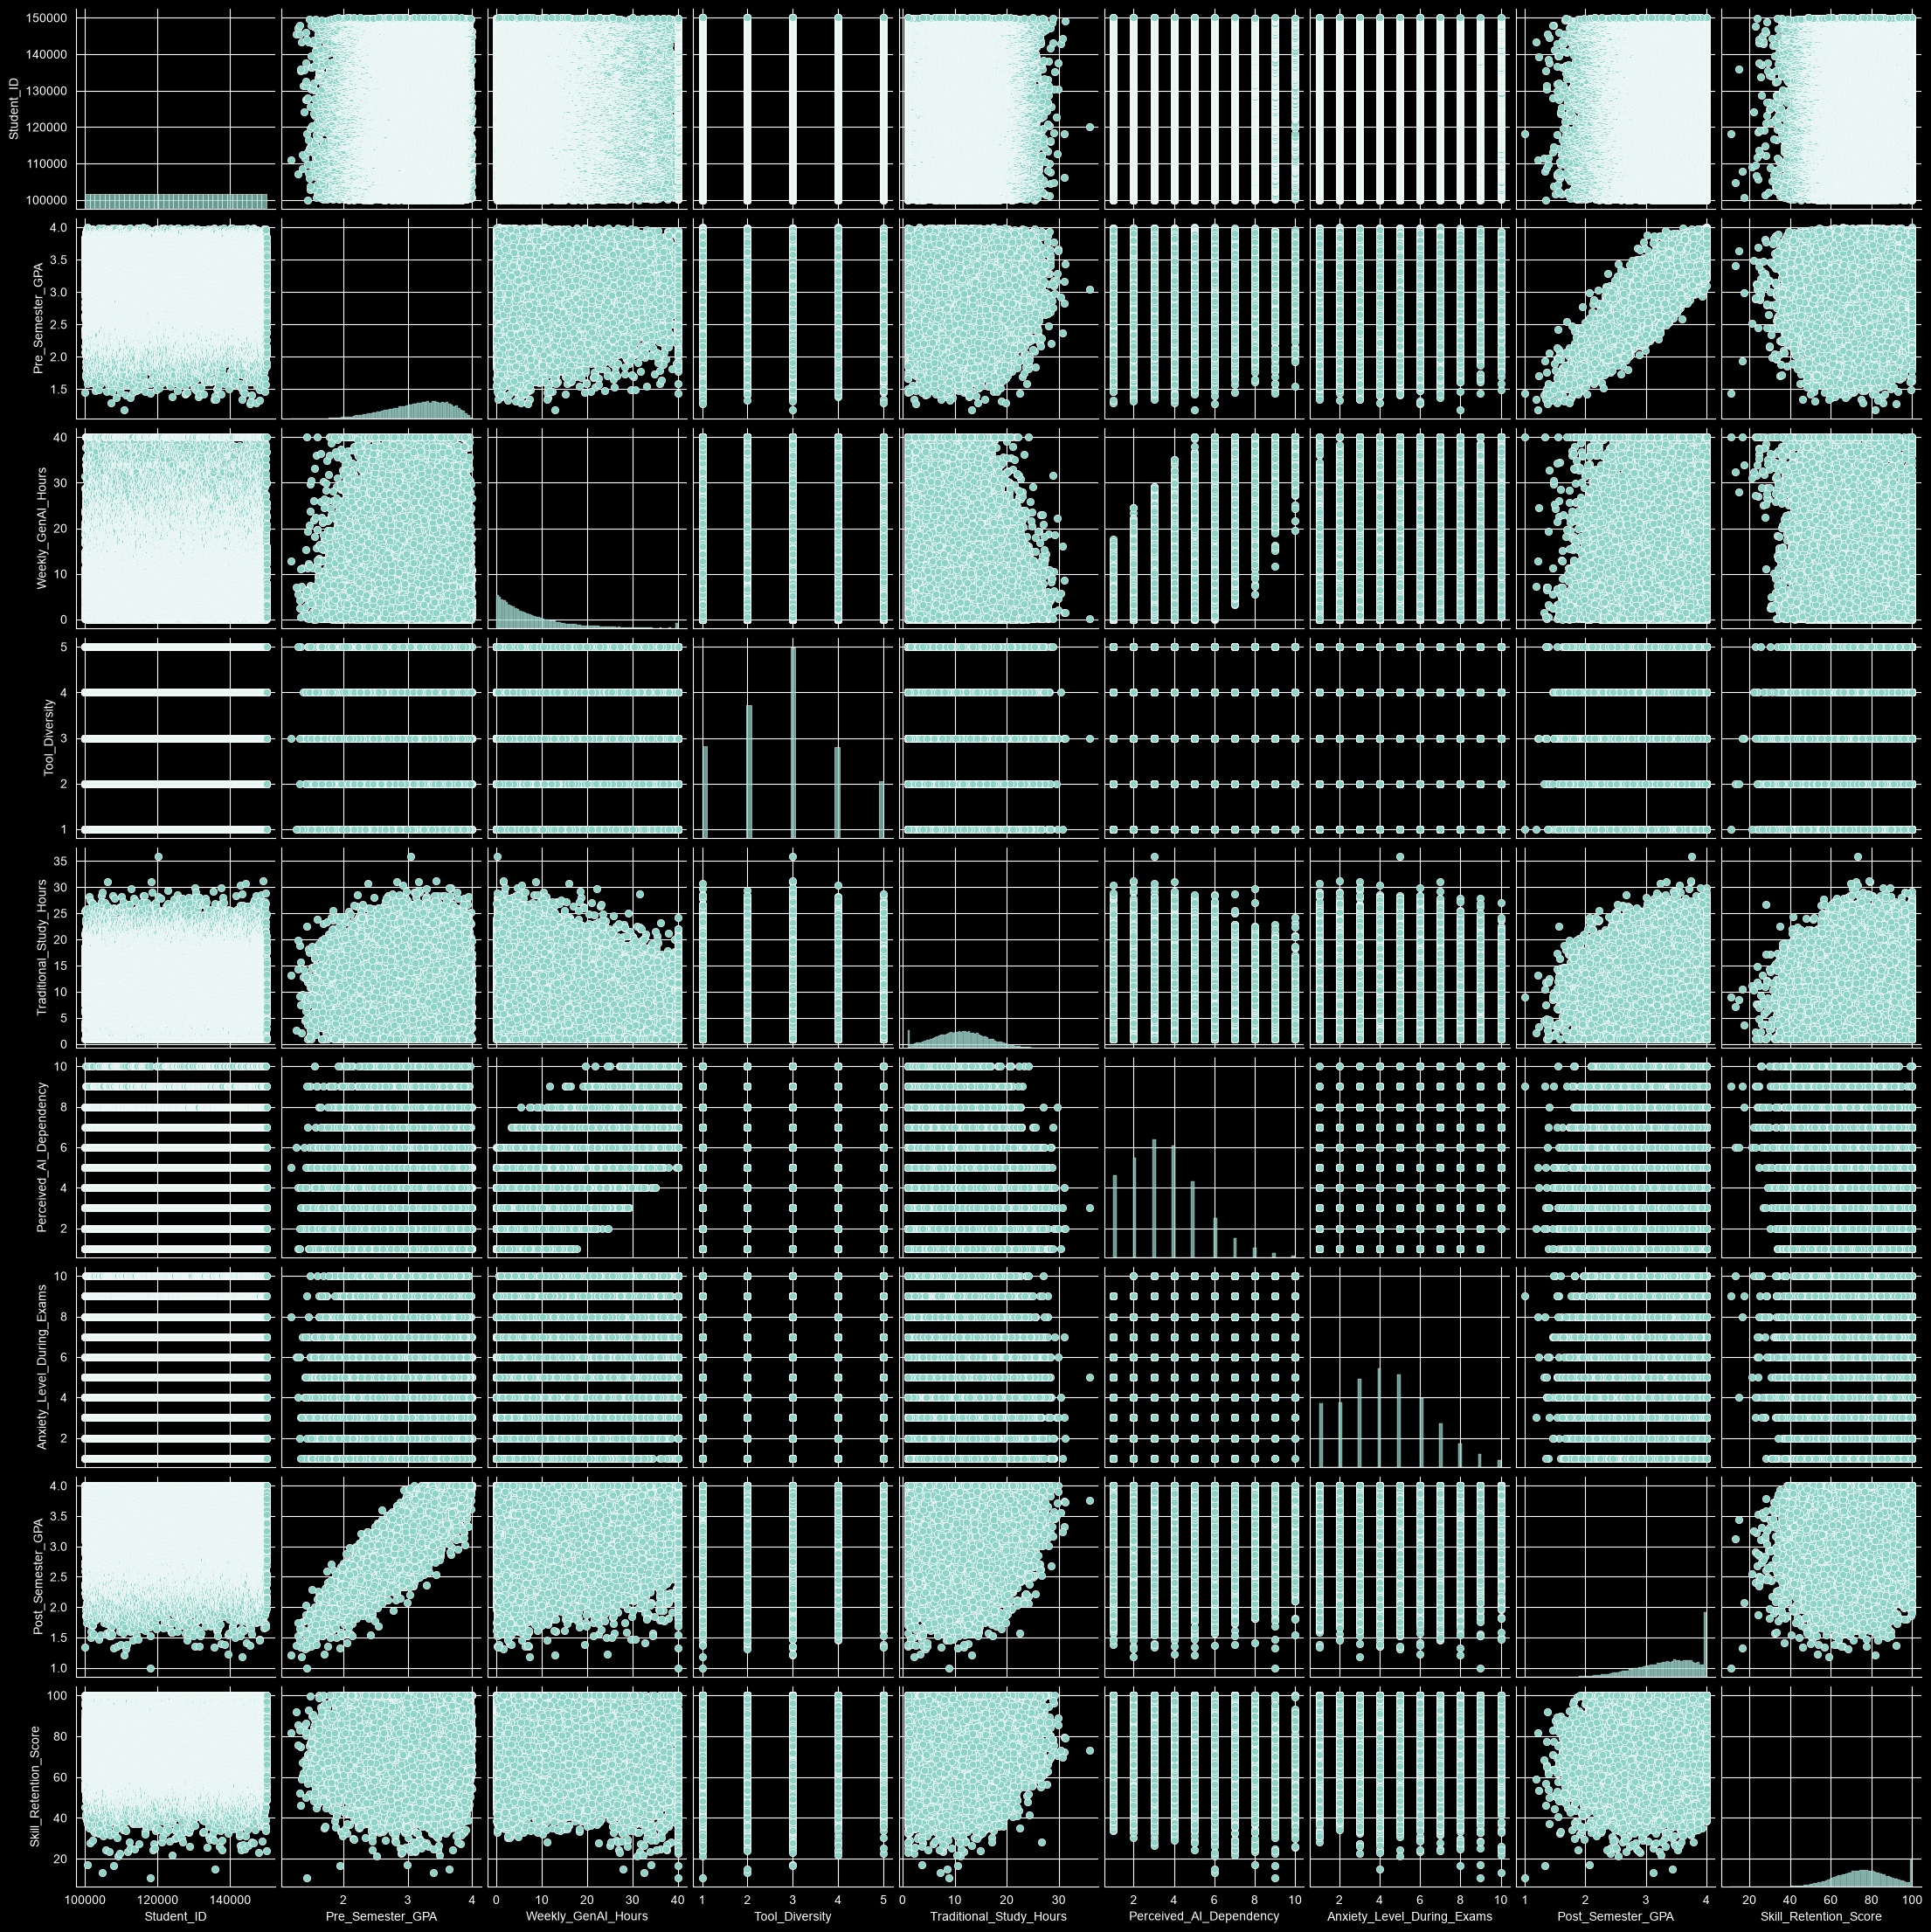

In [7]:
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

sns.pairplot(df_clean[numeric_columns])
plt.show()

<b>Interpretation Pairplot:</b>
<br>
<table>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Einfluss auf Post_Semester_GPA (Abschlussnote)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Stark positiv</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Stark positiv (oder die Folge guter Noten)</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Schwach positiv</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Kein klarer linearer Effekt</td>
    </tr>
    <tr>
      <td>Anxiety / AI_Dependency</td>
      <td>Kein klarer Effekt sichtbar</td>
    </tr>
  </tbody>
</table>

Anhand des obigen Pairplots lassen sich Trends für die Variablen "Pre_Semester_GPA", "Weekly_GenAI_Hours", "Traditional_Study_Hours", "Post_Semester_GPA", "Skill_Retention_Score", "Perceived_AI_Dependency" erkennen. Diese werden im nachfolgenden Plot gesondert dargestellt.

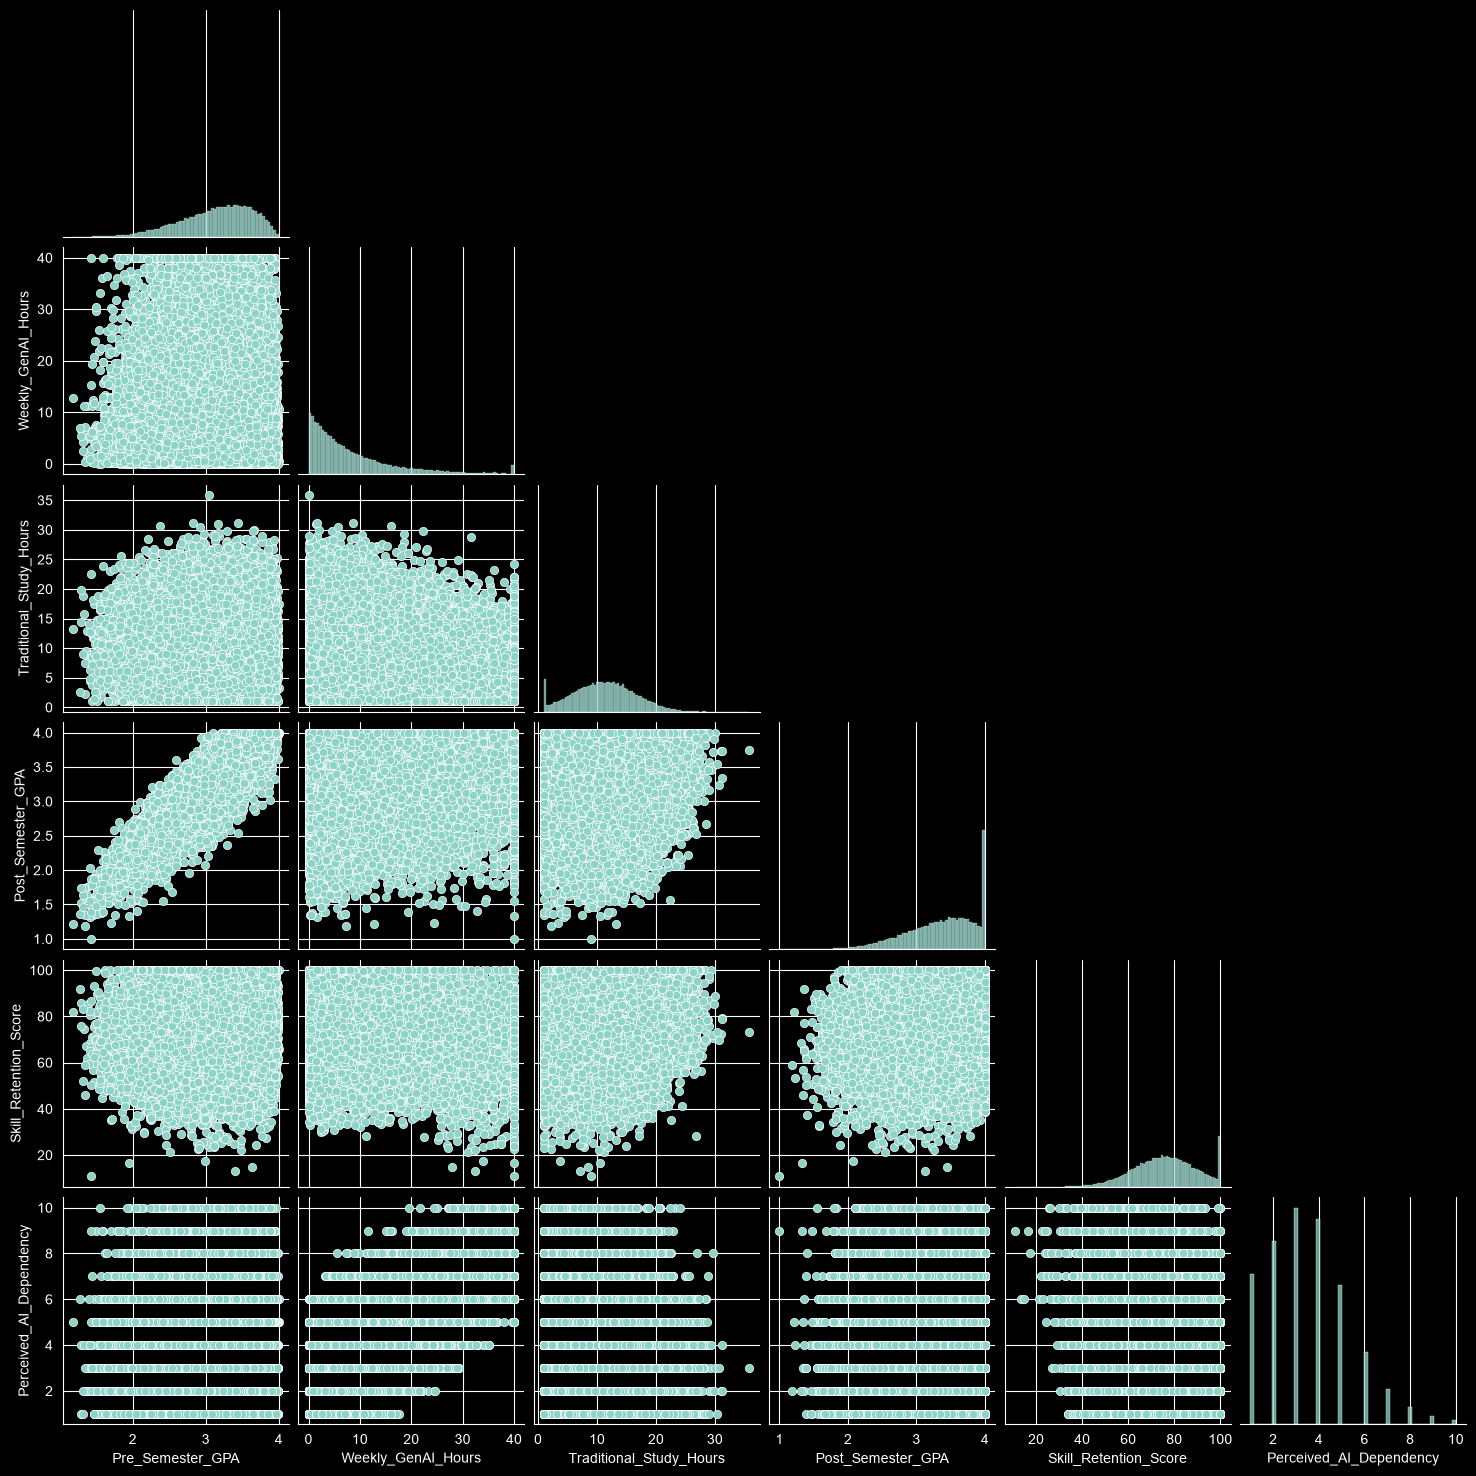

In [8]:
pairplot_cols = [
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Post_Semester_GPA",
    "Skill_Retention_Score",
    "Perceived_AI_Dependency"
]

sns.pairplot(
    df[pairplot_cols],
    corner=True,
    diag_kind="hist"
)

plt.show()

Das reduzierte Pairplot zeigt eine Korrelation für **Post_-** und **Pre_Semester_GPA**, ebenso besteht der Verdacht auf einen Zusammenhang zwischen **Weekly_GenAI_Hours** und **Perceived_AI_Dependency**.

<b>Regression oder Klassifikation:</b>
<br>
Kurzbeschreibung _**Regression**_: Regression ist ein Verfahren, mit dem ein numerischer Wert vorhergesagt wird. Dabei wird untersucht, wie sich eine oder mehrere unabhängige Variablen auf eine abhängige Variable auswirken.
<br>
Kurzbeschreibung _**Klassifikation**_: Klassifikation ist ein Verfahren, bei dem Daten vordefinierten Kategorien oder Klassen zugeordnet werden. Das Ziel besteht darin, anhand vorhandener Merkmale die richtige Klasse vorherzusagen.
<br>
Output Variable :
Post_Semester_GPA (Die Note nach dem Semester, Wertebereich = 1.0–4.0, kontinuierliche Variable)
<br>
<br>
Input Variablen:
<table>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Datentyp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Tool_Diversity</td>
      <td>Diskret (1–5)</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Perceived_AI_Dependency</td>
      <td>Ordinal (1–10)</td>
    </tr>
    <tr>
      <td>Anxiety_Level_During_Exams</td>
      <td>Ordinal (1–10)</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>One-Hot-Encoded Variablen</td>
      <td>Binär (0/1)</td>
    </tr>
  </tbody>
</table>


<b>Empfehlung Regression:</b>

1. Der GPA ist eine kontinuierliche Variable mit vielen möglichen Werten (1.0, 1.1, 1.2, ... 4.0). Regression modelliert genau derartige Zusammenhänge.
2. Drohender Informationsverlust bei Klassifikation: Würde man den GPA in Klassen einteilen, ginge die Abstufung verloren. Ein Unterschied zwischen 2.9 und 3.1 wäre nicht mehr messbar, obwohl er existiert.

Für eine Klassifikation müsste eine angepasste Frage bspw. lauten:
"Besteht ein Student (Klassifikation in Ja oder Nein) anhand von Parameter x + y + z?".


<b>Fragestellung für Prediction und Inference</b>
<br>
<br>
Inference Frage: Welchen _Einfluss_ haben die einzelnen Input-Variablen auf den Post_Semester_GPA?

Prediction Frage: Wie _präzise_ lässt sich anhand der Input-Variablen der Post_Semester_GPA eines Studierenden vorhersagen?

**TODO Einbinden der Studie an dieser Stelle?**

<b>Training und Fitting für einen Regression Tree:</b>
<br>
<br>
1: Aufteilung des Datensatzes in Trainings und Testdaten (80/20 Split).<br>
2: Suche nach optimalen Parametern (im Fokus : max_depth, min_sample_leaf, ccp_alpha).<br>
3: Erstellung eines Baumes mit optimalen Parametern.<br>
4: Overfitting Check.<br>
5: Visualisierung des Overfitting.<br>
6: Erzeugung einer Vorhersage.<br>
7: Evaluation des Baumes nach R2-Score und Feature Importance.<br>
8: Visualisierung des Baumes.<br>

<b>Aufteilung in Training & Testdaten(1) + Suche nach Parametern(2)</b>

In [9]:
# Drop der STUDENT_ID aufgrund ihrer Irrelevanz
df_encoded = df_encoded.drop(columns=["Student_ID"])

Die Student_ID bietet keinerlei Mehrwert für die Auswertung. Damit das Modell kein Muster in die ID und Post_Semester_GPA hereininterpretiert, wird diese Spalte ausgeschlossen.

In [10]:
# Festlegung der Zielvariablen
target = "Post_Semester_GPA"

random_state_unique = 42
# Drop des targets aus der df_encoded
X = df_encoded.drop(columns=[target])

# Definition des Targets als y
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= random_state_unique
)

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [10, 50, 100, 200],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'min_samples_split': [20, 100, 200, 400]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,                
    scoring='r2',
    return_train_score=True
)
grid_search.fit(X_train, y_train)
print("Beste Parameter:", grid_search.best_params_)
print("Bester CV R²:", grid_search.best_score_)

Beste Parameter: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 100}
Bester CV R²: 0.8818402772521304


<b>Erstellung des Trees mit optimalen Parametern(3)</b>

**TODO tree.fit(X_test, y_test)**

Wo sollte der Tree umgestellt werden?<br>
Soll er überhaupt umgestellt werden?

In [11]:
tree = DecisionTreeRegressor(
    max_depth = grid_search.best_params_['max_depth'],
    random_state = random_state_unique,
    min_samples_leaf = grid_search.best_params_['min_samples_leaf'],
    min_samples_split = grid_search.best_params_['min_samples_split'],
    ccp_alpha = grid_search.best_params_['ccp_alpha']
)

tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes

<b>Overfitting-Check(4)</b>
<br>
<br>
Um Overfitting festzustellen werden die Ergebnisse der Test und Trainingsdaten Prediction mit dem R2 Score gegeneinander verglichen.


In [12]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("Overfitting-Check")
print(f"R² Training: {r2_score(y_train, y_train_pred):.4f}")
print(f"R² Test:     {r2_score(y_test, y_test_pred):.4f}")
print(f"Differenz:   {r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred):.4f}")
print()
print(f"RMSE Training: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"RMSE Test:     {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")


Overfitting-Check
R² Training: 0.9004
R² Test:     0.8841
Differenz:   0.0163

RMSE Training: 0.1568
RMSE Test:     0.1673


**TODO - Interpretation des R²**

Das R²-Training=**0.9** sowie R²-Test=**0.88** weisen auf eine hohe Modellgüte hin. Die nur minimalen Unterschiede zwischen Trainings- und Testdaten deuten darauf hin, dass kein relevantes Overfitting vorliegt und das Modell eine hohe Generalisierungsfähigkeit besitzt.

<b>Overfitting Visualisierung(5)</b>

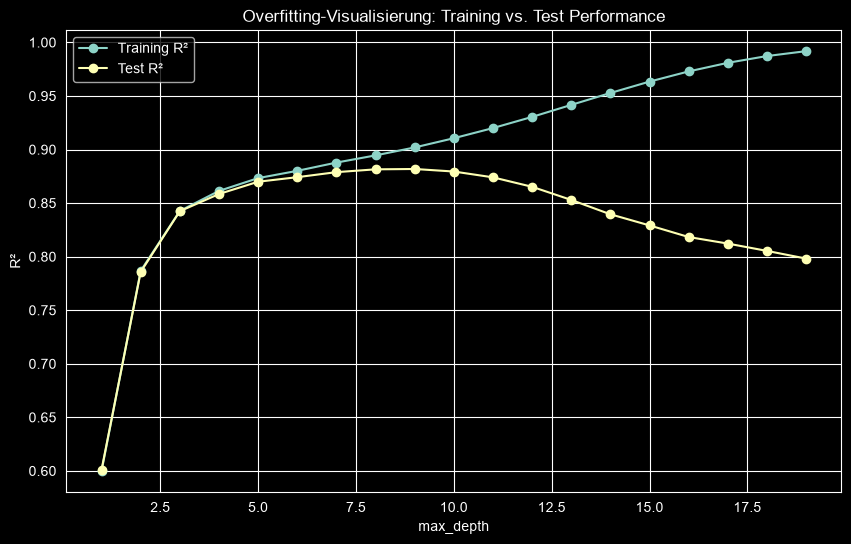

In [13]:
train_scores = []
test_scores = []
depths = range(1, 20)
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Training R²', marker='o')
plt.plot(depths, test_scores, label='Test R²', marker='o')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Overfitting-Visualisierung: Training vs. Test Performance')
plt.legend()
plt.grid(True)
plt.show()

**Beschreibung des Schaubilds**

Das Diagramm zeigt die Entwicklung des Bestimmtheitsmaßes R² eines Entscheidungsbaum-Modells in Abhängigkeit von der maximalen Baumtiefe (max_depth). Dabei werden die Modellleistungen auf den Trainingsdaten und den Testdaten gegenübergestellt, um mögliches Overfitting zu erkennen.

Der zunehmende Abstand zwischen Trainings- und Test-R² bei größeren Baumtiefen deutet auf Overfitting hin.

Das Diagramm legt nahe, dass die optimale Baumtiefe im Bereich von 8 bis 10 Ebenen liegt. In diesem Bereich erreicht das Modell die höchste Vorhersageleistung auf den Testdaten und bietet den besten Kompromiss zwischen Modellgenauigkeit und Generalisierungsfähigkeit.

<b>Erzeugung einer Vorhersage(6)</b>

In [14]:
#tree.fit(X_test, y_test)
y_pred = tree.predict(X_test)

print("Prediction :", y_pred)

Prediction : [2.35435106 3.10868493 3.0641     ... 3.41408163 3.01549123 3.21140887]


<b>Evaluation des Baums nach R2 Score und Feature Importance(7)</b>
<br>
<br>
Warum R2-Score als Evaluationsmetrik:<br>
Um mit Recall, Precision oder F1 Score zu evaluieren, müsste die Zielgröße angepasst werden, da diese Metriken üblicherweise für Klassifikation genutzt werden nicht Regression.

In [15]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

R²: 0.8840802225476223


,Feature,Importance
0,Pre_Semester_GPA,0.957787
4,Traditional_Study_Hours,0.023674
1,Weekly_GenAI_Hours,0.004966
7,Skill_Retention_Score,0.003728
17,Primary_Use_Case_Direct_Answer_Generation,0.002396
16,Primary_Use_Case_Debugging/Troubleshooting,0.001994
14,Year_of_Study_Senior,0.001344
12,Year_of_Study_Graduate,0.001069
21,Prompt_Engineering_Skill_Intermediate,0.001006
20,Prompt_Engineering_Skill_Beginner,0.000519


<b>Evaluation der Ergebnisse</b>
<br>
<br>
To be done:<br>
Die wichtigsten Entscheidungsregeln des Modells<br>
Welche Parameter hatten den größten Einfluss auf die Modellqualität?<br>
Wie konnte Overfitting reduziert werden?<br>
Interpretieren Sie die Ergebnisse der Evaluation: Mit welchen Einstellungen konnten Sie die besten Ergebnisse erreichen?


<b>Baum visualisieren (Mehr als fünf Ebenen erzeugen hohe Wartezeiten (Parameter max_depth))(8)</b>

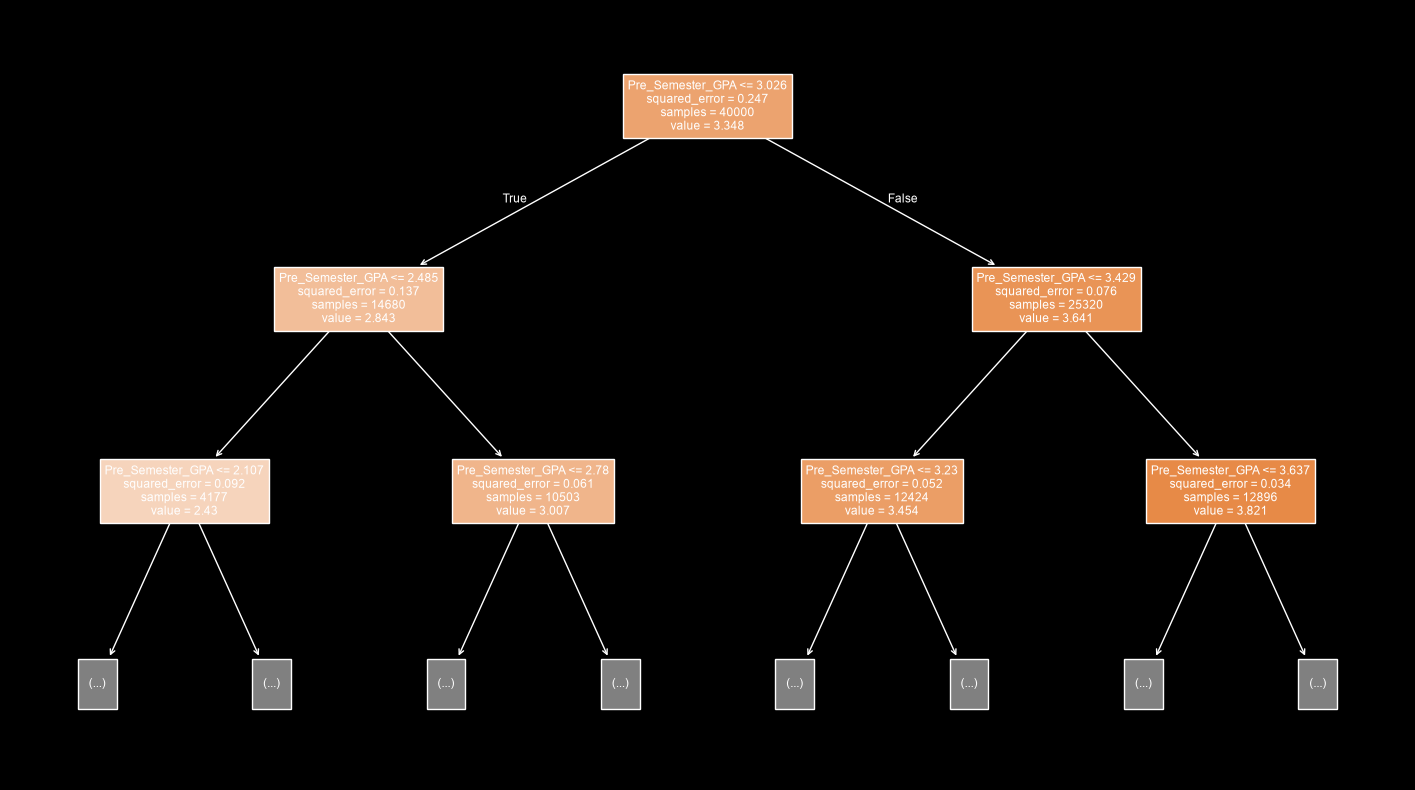

In [18]:
plt.figure(figsize=(18,10))

plot_tree(
    tree,
    max_depth=2,
    filled=True,
    feature_names=X.columns
)

plt.show()